# Data Space I: What Claims Can This Dataset Support?

## 0. Introduction: The Dataset Is Not the Relationship

A dataset is not the relationship. A dataset is evidence produced by an observation process. A fitted curve may look convincing, but its validity depends on the claim being made. Before fitting a model, we must ask what the data can support.

The chain in this notebook is:

$$
\text{real relationship}
\rightarrow
\text{observation process}
\rightarrow
\text{dataset}
\rightarrow
\text{claim}.
$$

The central question is:

$$
\text{What claim does this dataset actually support?}
$$

The running example is a tilt-power study:

$$
X=\text{observed tilt angle},
\qquad
Y=\text{observed power output}.
$$

The researcher may care about a latent true tilt $\Theta$, hidden context $C$, measurement noise, and sampling choices, but the learner only receives observed pairs:

$$
\mathcal{D}=\{(x_i,y_i)\}_{i=1}^{n}.
$$

Here $\mathcal{D}$ is the finite dataset: $x_i$ is the observed tilt in sample $i$, $y_i$ is the observed power output in sample $i$, and $n$ is the number of observed samples. This notation is introduced to keep the notebook focused on the evidence actually available to the learner.

Across the workshop, the global frame is $\mathcal{H}+\mathcal{D}+\mathcal{O}\rightarrow s$: model class, data, optimisation procedure, and selected solution. This notebook isolates $\mathcal{D}$: what the data reveal, what they hide, and what claims they can support.

The audit has four questions.

| Question | What it asks |
|---|---|
| What can the learner see? | Which variables are observed, and which are hidden? |
| What claim are we trying to make? | What target relationship or estimand matters? |
| Where does the data provide evidence? | Where is there enough relevant local data? |
| What remains ambiguous? | Which alternative explanations still fit? |


### Setup

This setup cell imports the shared toy-data helpers used throughout the notebook. It changes only the Python environment for the demonstration; the data-generating examples below choose their own sample sizes, noise levels, and sampling rules. Look for the same axes, colours, and latent tilt-power curve to appear across the examples.


In [42]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = next(
    (path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src" / "nextgen2026_mlai_workshops").exists()),
    Path.cwd(),
)
src_dir = PROJECT_ROOT / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

module_name = "nextgen2026_mlai_workshops"
if module_name in sys.modules:
    del sys.modules[module_name]

from nextgen2026_mlai_workshops.data_space import (
    COLORS,
    configure_matplotlib,
    f0,
    gaussian_smoother,
    local_count,
    plot_observed,
    plot_reference,
    sample_tilt_power,
    style_xy_axis,
    theta_grid,
)

configure_matplotlib()

print("Setup complete. The notebook uses fixed synthetic examples for interpretation.")


Setup complete. The notebook uses fixed synthetic examples for interpretation.


## 1. What Can the Learner See?

### Motivation

Before fitting a model, we need to separate what the learner observes from what the researcher imagines is happening underneath. This prevents a common mistake: treating a scatter plot of $(X,Y)$ as if it directly revealed the physical relationship. In the plot below, look for the difference between the unlabelled dataset and the hidden context that generated different responses.

### Minimal example

This plot is designed to show that the learner receives only observed $(X,Y)$ pairs, while the teaching view can reveal information that the learner did not get. The cell changes only the display of hidden context; the underlying dataset is held fixed. Look for how the same points become easier to explain once context labels are revealed.


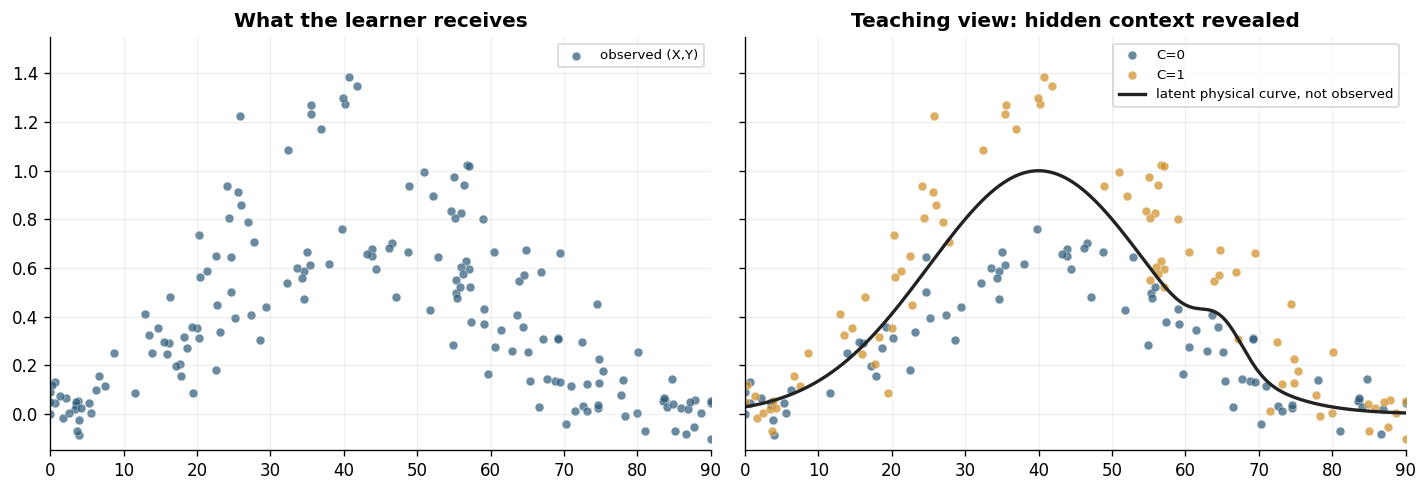

In [43]:
observed_data = sample_tilt_power(
    n=170,
    scenario="hidden_context",
    seed=21,
    x_noise=4.0,
    y_noise=0.06,
    context_strength=0.35,
    sampling="uniform",
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True, sharey=True)

plot_observed(axes[0], observed_data, reveal_context=False, alpha=0.72)
style_xy_axis(axes[0])
axes[0].set_title("What the learner receives")
axes[0].legend(loc="upper right", fontsize=8)

plot_observed(axes[1], observed_data, reveal_context=True, alpha=0.72)
plot_reference(axes[1], label="latent physical curve, not observed")
style_xy_axis(axes[1])
axes[1].set_title("Teaching view: hidden context revealed")
axes[1].legend(loc="upper right", fontsize=8)

fig.tight_layout()
plt.show()


### Plot interpretation

What to notice:

- The left panel is the dataset available to the learner: observed tilt $X$ and observed output $Y$.
- The right panel reveals hidden context $C$ and the latent physical curve for teaching, but those are not columns in the learner's dataset.
- This data can support a claim about the observed mixture of outputs as a function of $X$.
- A claim about a context-specific mechanism or the exact physical response would be risky without measuring the hidden variables. This plot answers: what can the learner see?

### Mathematical object

The visual motivates a simple observation model. It is introduced after the plot because the point is not the equation itself; the point is that observed columns may be only proxies for the process the researcher cares about.

$$
X = \Theta + \varepsilon_X
$$

Here $\Theta$ is the true physical tilt, $X$ is the observed tilt measured by the learner, and $\varepsilon_X$ is input measurement error. This equation diagnoses whether the model is trained on the physical input or on a noisy proxy.

$$
Y = f(\Theta,C) + \varepsilon_Y
$$

Here $Y$ is the observed output, $f(\Theta,C)$ is the response that depends on true tilt and hidden context, $C$ is hidden context, and $\varepsilon_Y$ is output noise. This equation diagnoses whether variation in $Y$ is learnable from $X$ alone or partly driven by information the learner cannot see.

Plain-language translation: if relevant information is not observed, a model cannot recover it by curve-fitting. It can only learn from the variables in the dataset.

**Conclusion.** The first limit of a dataset is observability. The learner can only use the variables it sees. If the research claim depends on hidden variables, the data may support only a mixture or proxy relationship. The central question remains: what claim does this dataset actually support?


## 2. What Claim Are We Trying to Make?

### Motivation

The same scatter plot can be used to ask different research questions, but those questions require different evidence. This section prevents the mistake of validating one claim and then speaking as if a stronger claim had been proven. Read the table as a claim checklist before choosing a model.

### Minimal example

The minimal example here is not another plot. It is a table that holds the observed dataset idea fixed while changing the research claim. Look for how the mathematical target and evidence requirement change even though the columns $(X,Y)$ may look the same.

### Mathematical object

An estimand is the target relationship a study is trying to estimate. The notation below is introduced to name four different targets that are often blurred together.

| Research claim | Mathematical target | Evidence required |
|---|---|---|
| Predict observed output from observed tilt | $\mathbb{E}[Y\mid X=x]$ | Representative observed $(X,Y)$ samples |
| Recover the physical curve | $f_0(\theta)$ or $\mathbb{E}[Y\mid \Theta=\theta]$ | Accurate measurement of $\Theta$, low noise, relevant context |
| Predict deployment behaviour | $P_{\mathrm{deploy}}(Y\mid X=x)$ | Data covering deployment conditions |
| Make a causal claim | $\mathbb{E}[Y\mid do(\Theta=x)]$ | Intervention, randomisation, or valid adjustment |

In the first row, $\mathbb{E}[Y\mid X=x]$ means the average observed output among cases with observed tilt near $x$. In the second row, $f_0(\theta)$ or $\mathbb{E}[Y\mid \Theta=\theta]$ refers to the physical response at true tilt $\theta$, which is a different target if $X$ is noisy or context is hidden. In the third row, $P_{\mathrm{deploy}}(Y\mid X=x)$ is the deployment distribution of outputs at observed tilt $x$. In the fourth row, $do(\Theta=x)$ means setting the true tilt by intervention rather than merely observing cases that happened to have that tilt.

This table helps diagnose whether the dataset contains the kind of evidence required by the claim. The same dataset can be strong evidence for observed prediction and weak evidence for physical recovery, deployment robustness, or causality.

### Plot interpretation

There is no plot in this section because the distinction is conceptual: the same visual data can imply different targets. What to notice:

- The learner observes the same $(X,Y)$ columns, but the research claim changes the target.
- Observed prediction can be supported by representative observed samples.
- Physical, deployment, and causal claims require additional measurement, coverage, or study design.
- This section answers: what claim are we trying to make?

**Conclusion.** Data adequacy is claim-relative. Before fitting a model, the researcher must say whether the goal is observed prediction, physical recovery, deployment prediction, or a causal claim. What claim does this dataset actually support is therefore not a modelling detail; it is the first modelling decision.


## 3. Where Does the Data Provide Evidence?

### Motivation

A fitted curve draws a value at every $x$, but the dataset may not provide evidence everywhere. This section prevents the mistake of treating a continuous model output as continuous empirical support. In the plot below, look for regions where the fitted curve is mostly evidence-driven and regions where it is partly assumption-driven.

### Minimal example

Coverage asks whether there are observations near the region we care about. Resolution asks whether those observations are dense and clean enough to distinguish the behaviour we care about. This plot is designed to show both ideas with one local evidence count: the data are held fixed, the fitted smoother is held fixed, and the shaded regions mark weak local support.


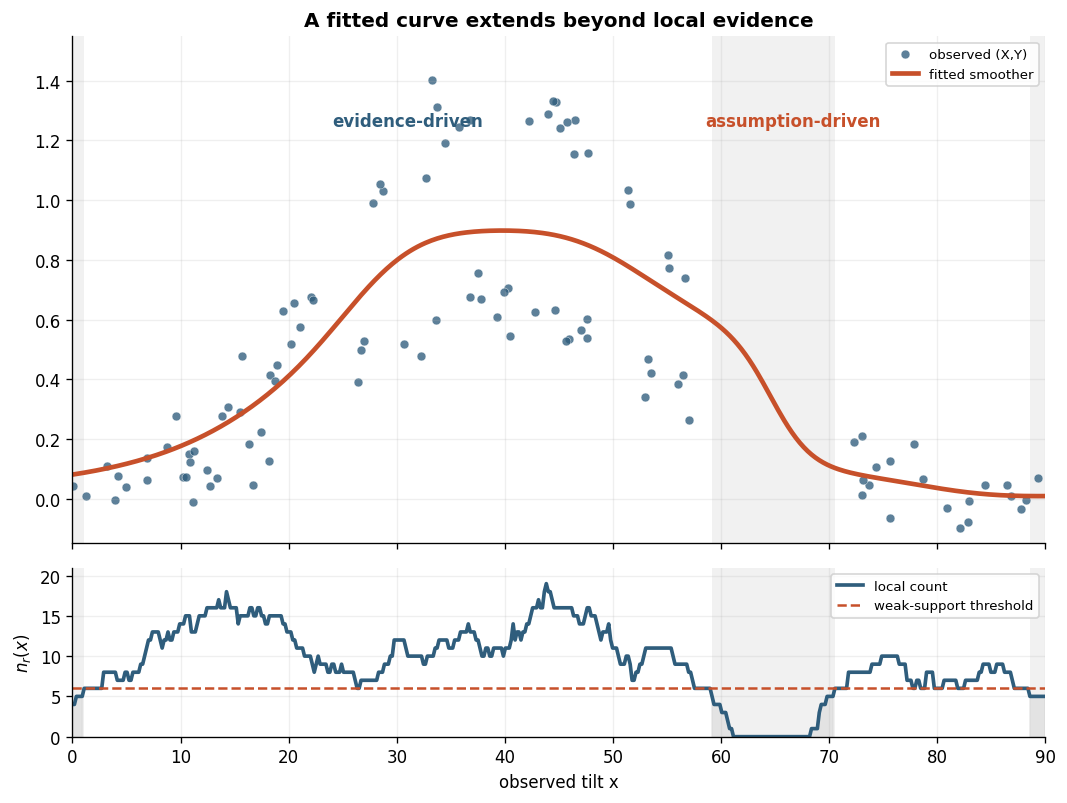

In [44]:
evidence_data = sample_tilt_power(
    n=105,
    scenario="output_noise",
    seed=45,
    y_noise=0.055,
    sampling="gap65",
)

radius = 4.0
min_count = 6
counts = local_count(theta_grid, evidence_data["x"], radius)
weak_support = counts < min_count
smooth = gaussian_smoother(evidence_data["x"], evidence_data["y"], theta_grid, bandwidth=6.0)

fig, (ax, ax_count) = plt.subplots(
    2,
    1,
    figsize=(9, 6.8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

for start, end, weak in zip(theta_grid[:-1], theta_grid[1:], weak_support[:-1]):
    if weak:
        ax.axvspan(start, end, color=COLORS["support"], alpha=0.35, lw=0)
        ax_count.axvspan(start, end, color=COLORS["support"], alpha=0.35, lw=0)

plot_observed(ax, evidence_data, alpha=0.78)
ax.plot(theta_grid, smooth, color=COLORS["fit"], lw=2.8, label="fitted smoother")
ax.text(24, 1.25, "evidence-driven", color=COLORS["data"], fontsize=10, weight="bold")
ax.text(58.5, 1.25, "assumption-driven", color=COLORS["fit"], fontsize=10, weight="bold")
style_xy_axis(ax)
ax.set_title("A fitted curve extends beyond local evidence")
ax.legend(loc="upper right", fontsize=8)

ax_count.plot(theta_grid, counts, color=COLORS["data"], lw=2.2, label="local count")
ax_count.axhline(min_count, color=COLORS["fit"], lw=1.5, ls="--", label="weak-support threshold")
ax_count.fill_between(theta_grid, 0, counts, where=weak_support, color=COLORS["support"], alpha=0.55)
ax_count.set_ylabel(r"$n_r(x)$")
ax_count.set_xlabel("observed tilt x")
ax_count.set_ylim(0, max(18, counts.max() + 2))
ax_count.grid(alpha=0.2)
ax_count.legend(loc="upper right", fontsize=8)

fig.tight_layout()
plt.show()


### Plot interpretation

What to notice:

- The fitted curve is drawn across the whole tilt range, including shaded regions with few nearby observations.
- Where the local count is high, the curve is more evidence-driven because nearby data constrain it.
- Where the local count is low, the curve is more assumption-driven because the fitting rule fills in behaviour the data do not locally resolve.
- This data may support interpolation in dense observed regions, but a claim about the missing feature near the gap would require more data or a different measurement design. This plot answers: where does the data provide evidence?

### Mathematical object

To make local support visible, define a local evidence count:

$$
n_r(x)=\sum_{i=1}^{n}\mathbf{1}\{|x_i-x|\leq r\}.
$$

Here $r$ is the local neighbourhood radius, $x_i$ is the observed tilt in sample $i$, $x$ is the location where we want to make a claim, $n$ is the sample size, and $\mathbf{1}\{\cdot\}$ equals 1 when the condition is true and 0 otherwise. The equation counts how many observed samples fall within distance $r$ of $x$. It helps diagnose whether a claim near $x$ is supported by local data or supplied mostly by assumptions.

Plain-language translation: $n_r(x)$ counts how many observed samples fall within distance $r$ of $x$. It is a local evidence count. If $n_r(x)$ is small, claims near $x$ are weakly supported.

Coverage and resolution are two parts of the same evidence question. Coverage asks whether observations exist near the region of interest; resolution asks whether those observations are dense and clean enough to distinguish the behaviour the claim requires.

**Conclusion.** The second limit of a dataset is local evidence. Claims are strongest where data are dense, relevant, and clean. In weakly covered or noisy regions, the model's behaviour is supplied partly by assumptions. The practical question is: what claim does this dataset actually support in the region that matters?


## 4. What Remains Ambiguous?

### Motivation

Even with low training error, the data may not identify a unique relationship. This section prevents the mistake of treating one selected curve as the only explanation compatible with the observations. In the plot below, look inside the data gap: the curves agree where the data constrain them and disagree where the data are silent.

### Minimal example

This plot is designed to show multiple plausible functions that fit the observed data similarly but imply different behaviour inside an unsupported region. The observed data and gap are held fixed; only the unobserved behaviour inside the gap changes. Look for disagreement where the research claim might care about the narrow feature.


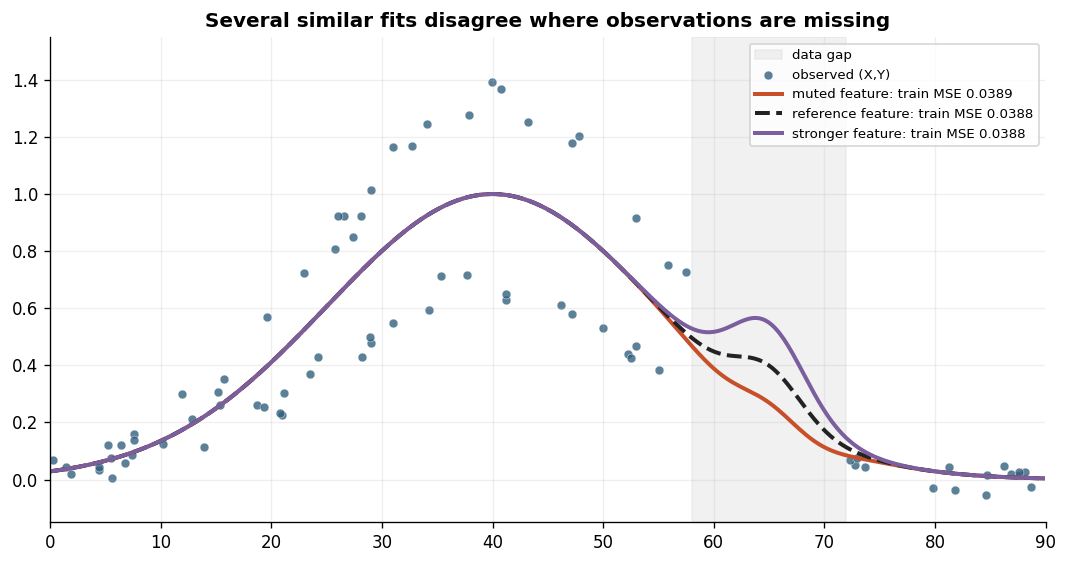

In [45]:
ambiguity_data = sample_tilt_power(
    n=78,
    scenario="output_noise",
    seed=70,
    y_noise=0.035,
    sampling="gap65",
)


def gap_bump(x, centre=65.0, width=4.0):
    return np.exp(-((np.asarray(x) - centre) ** 2) / (2 * width**2))


curves = [
    ("muted feature", lambda x: f0(x) - 0.13 * gap_bump(x), COLORS["fit"], "-"),
    ("reference feature", lambda x: f0(x), COLORS["truth"], "--"),
    ("stronger feature", lambda x: f0(x) + 0.15 * gap_bump(x), COLORS["alt"], "-"),
]

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.axvspan(58, 72, color=COLORS["support"], alpha=0.35, label="data gap")
plot_observed(ax, ambiguity_data, alpha=0.78)

for name, fn, color, linestyle in curves:
    train_mse = np.mean((fn(ambiguity_data["x"]) - ambiguity_data["y"]) ** 2)
    ax.plot(
        theta_grid,
        fn(theta_grid),
        color=color,
        lw=2.4,
        ls=linestyle,
        label=f"{name}: train MSE {train_mse:.4f}",
    )

style_xy_axis(ax)
ax.set_title("Several similar fits disagree where observations are missing")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()


### Plot interpretation

What to notice:

- The observed points leave a visible gap near the narrow feature.
- The curves have similar training errors because the altered behaviour is concentrated where there are few or no observations.
- The data support agreement in observed regions better than a unique claim inside the gap.
- A claim about the feature in the gap would be unsupported or risky without targeted samples. This plot answers: what remains ambiguous?

### Mathematical object

The version space is the set of explanations that fit the observed data about equally well. The notation below names that set so we can ask whether plausible explanations agree where the claim matters.

$$
\mathcal{V}_{\varepsilon}(\mathcal{D})
=
\left\{
h\in\mathcal{H}:
\widehat{R}(h)
\leq
\inf_{h'\in\mathcal{H}}\widehat{R}(h')+\varepsilon
\right\}.
$$

Here $\mathcal{V}_{\varepsilon}(\mathcal{D})$ is the set of plausible functions under the data, $h$ is one candidate function, $\mathcal{H}$ is the class of candidate functions, $\widehat{R}(h)$ is empirical error on the observed dataset, and $\varepsilon$ is the tolerance for a similarly good fit. The term $\inf_{h'\in\mathcal{H}}\widehat{R}(h')$ is the best empirical error available inside the hypothesis class.

This equation helps diagnose identifiability. If functions in $\mathcal{V}_{\varepsilon}(\mathcal{D})$ disagree where the claim matters, then low training error has not identified the relationship needed for that claim.

Plain-language translation: low training error does not mean the relationship has been identified. It may only mean that several different explanations all match the limited observations.

**Conclusion.** The third limit of a dataset is ambiguity. If several plausible functions fit the observations but disagree where the claim matters, then the data do not support a unique relationship there. The evidence audit asks: what claim does this dataset actually support, and what remains unresolved?


## 5. Optional Capstone: What Happens Under Deployment Shift?

### Motivation

Validation results are also claim-relative. A random split can test performance under a similar observation process, but it does not prove that the learned relationship will hold when deployment conditions change. This section prevents the mistake of converting same-process prediction evidence into deployment robustness evidence.

### Minimal example

The minimal example is a compact validation audit. It holds the idea of testing fixed while changing the test setting. Look for what each setting checks and what it does not prove.

A random split tests performance under a similar observation process. It does not prove the learned relationship will hold when the deployment distribution changes.

| Test setting | What it checks | What it does not prove |
|---|---|---|
| Random split | Same-process prediction | Robustness to shifted context |
| Balanced context | Sensitivity to context mixture | Causal effect |
| Shifted context | Deployment stress | Full physical recovery |

### Mathematical object

No new equation is needed here. The mathematical target is already one of the estimands from Section 2: same-process prediction targets the observed data-generating process, while deployment prediction targets $P_{\mathrm{deploy}}(Y\mid X=x)$. The table diagnoses whether the validation setting matches the claim.

### Plot interpretation

There is no plot in this capstone because the point is the claim attached to the validation design. What to notice:

- A random split can support same-distribution prediction.
- A balanced-context test can reveal sensitivity to a context mixture.
- A shifted-context test is a deployment stress test, not proof of the physical curve.
- This section returns to the question: what claim are we trying to make?

**Conclusion.** Robustness is also claim-relative. A model can be validated for one setting and unsupported for another. What claim does this dataset actually support depends on whether the observation process in the data matches the setting where the claim will be used.


## 6. Final Claim Audit

### Motivation

The final audit turns the notebook into a pre-modelling checklist. It prevents the mistake of asking only which model fits best, when the prior question is whether the data can support the claim at all. Read each row as a way to separate supported claims from claims that require more data, different measurements, or a different study design.

### Minimal example

This table returns to the four questions: what the learner can see, what claim matters, where the data provide evidence, and what remains ambiguous.

| Situation | What the data may support | What remains unsupported |
|---|---|---|
| Dense, clean data over the target region | Local prediction or interpolation | Causal or deployment claims without further assumptions |
| Data gap near an important feature | Broad trend outside the gap | Claim about the missing feature |
| Hidden context unmeasured | Mixture prediction from $X$ | Context-specific mechanism |
| Random split works | Same-distribution prediction | Robustness under shifted context |
| Multiple curves fit | Agreement in observed regions | Unique relationship elsewhere |

### Mathematical object

No new notation is needed in the final audit. The checklist uses the objects already introduced: observed variables $(X,Y)$, the claim or estimand, local evidence $n_r(x)$, and the version space of plausible fits. Together they diagnose what the dataset can and cannot justify.

### Plot interpretation

There is no final plot because the takeaway is a decision table. What to notice:

- Observability limits what the learner can use.
- The estimand determines what evidence is required.
- Coverage and resolution determine where the claim is locally supported.
- Identifiability asks whether unresolved alternatives still fit.

**Conclusion.** The notebook's core lesson is not that one model is better than another. The lesson is that data justify claims only under specific observation, coverage, resolution, and ambiguity conditions. Before fitting a model, a researcher should ask: what claim does this dataset give evidence for, and what claim would require more data, different measurements, or a different study design?
